In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\Drug.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na,K,Drug
0,23,F,HIGH,HIGH,0.792535,0.031258,drugY
1,47,M,LOW,HIGH,0.739309,0.056468,drugC
2,47,M,LOW,HIGH,0.697269,0.068944,drugC
3,28,F,NORMAL,HIGH,0.563682,0.072289,drugX
4,61,F,LOW,HIGH,0.559294,0.030998,drugY


In [3]:
df['Drug'].unique()

array(['drugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

C:\Users\Asus\AppData\Local\Temp\ipykernel_31624\1361194014.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Drug']=='drugY']['Age'],color='green')
C:\Users\Asus\AppData\Local\Temp\ipykernel_31624\1361194014.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Drug']=='drugC']['A

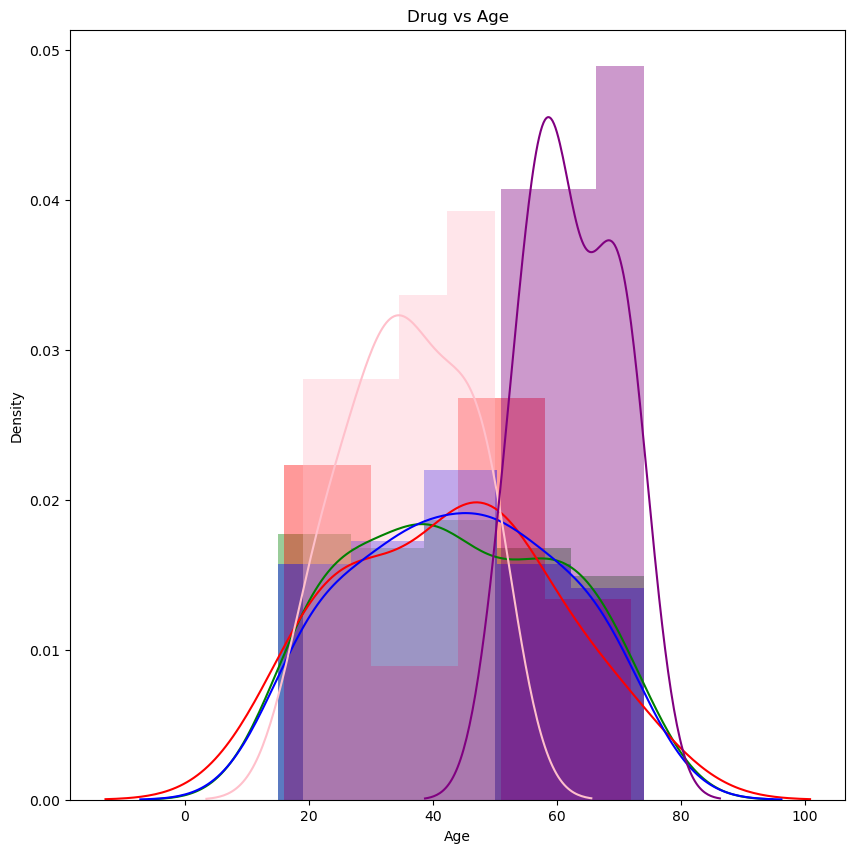

In [4]:
plt.figure(figsize=(10,10))
sns.distplot(df[df['Drug']=='drugY']['Age'],color='green')
sns.distplot(df[df['Drug']=='drugC']['Age'],color='red')
sns.distplot(df[df['Drug']=='drugX']['Age'],color='blue')
sns.distplot(df[df['Drug']=='drugA']['Age'],color='pink')
sns.distplot(df[df['Drug']=='drugB']['Age'],color='purple')
plt.title("Drug vs Age")
plt.show()

In [5]:
from sklearn.preprocessing import OrdinalEncoder
oc=OrdinalEncoder()
df['Sex']=oc.fit_transform(df[['Sex']])
df['Cholesterol']=oc.fit_transform(df[['Cholesterol']])
df['BP']=oc.fit_transform(df[['BP']])
df['Drug']=oc.fit_transform(df[['Drug']])
df.head()

,Age,Sex,BP,Cholesterol,Na,K,Drug
0,23,0.0,0.0,0.0,0.792535,0.031258,4.0
1,47,1.0,1.0,0.0,0.739309,0.056468,2.0
2,47,1.0,1.0,0.0,0.697269,0.068944,2.0
3,28,0.0,2.0,0.0,0.563682,0.072289,3.0
4,61,0.0,1.0,0.0,0.559294,0.030998,4.0


- X and y

In [6]:
X=df.drop('Drug',axis=1)
y=df['Drug']

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [9]:
from sklearn.tree import DecisionTreeClassifier
clf_gini=DecisionTreeClassifier(criterion='gini',random_state=0)
clf_gini.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

In [10]:
y_pred_train=clf_gini.predict(X_train)
y_pred_train

array([3., 3., 3., 4., 4., 2., 4., 4., 4., 3., 3., 4., 3., 4., 3., 4., 0.,
       4., 4., 4., 0., 4., 1., 4., 3., 4., 4., 4., 4., 1., 3., 3., 3., 1.,
       0., 3., 4., 3., 0., 3., 2., 4., 0., 0., 0., 1., 1., 0., 4., 0., 4.,
       4., 0., 4., 4., 4., 3., 4., 3., 4., 4., 3., 1., 3., 4., 0., 2., 4.,
       3., 3., 4., 4., 3., 3., 1., 4., 1., 3., 4., 4., 4., 1., 2., 0., 4.,
       4., 4., 0., 3., 3., 4., 2., 4., 4., 3., 1., 3., 3., 4., 4., 4., 4.,
       4., 4., 1., 3., 2., 0., 4., 0., 0., 3., 4., 4., 4., 4., 3., 4., 0.,
       3., 4., 4., 3., 4., 3., 1., 4., 4., 2., 3., 4., 4., 4., 4., 3., 4.,
       3., 3., 4., 2., 2., 4., 2., 4., 1., 3., 4., 3., 4., 4., 4., 3., 4.,
       4., 4., 3., 3., 4., 4., 2.])

In [11]:
y_pred_test=clf_gini.predict(X_test)
y_pred_test

array([3., 0., 3., 2., 4., 4., 4., 3., 0., 3., 0., 3., 4., 4., 1., 4., 1.,
       3., 2., 4., 1., 3., 3., 4., 4., 4., 2., 3., 4., 4., 4., 2., 4., 4.,
       0., 4., 3., 0., 4., 0.])

In [12]:
from sklearn.metrics import accuracy_score
print("accuracy score for train data:",accuracy_score(y_pred_test,y_test))
from sklearn.model_selection import cross_val_score
print("cross val score:",cross_val_score(clf_gini,X,y,cv=5).mean())

accuracy score for train data: 0.9
cross val score: 0.885


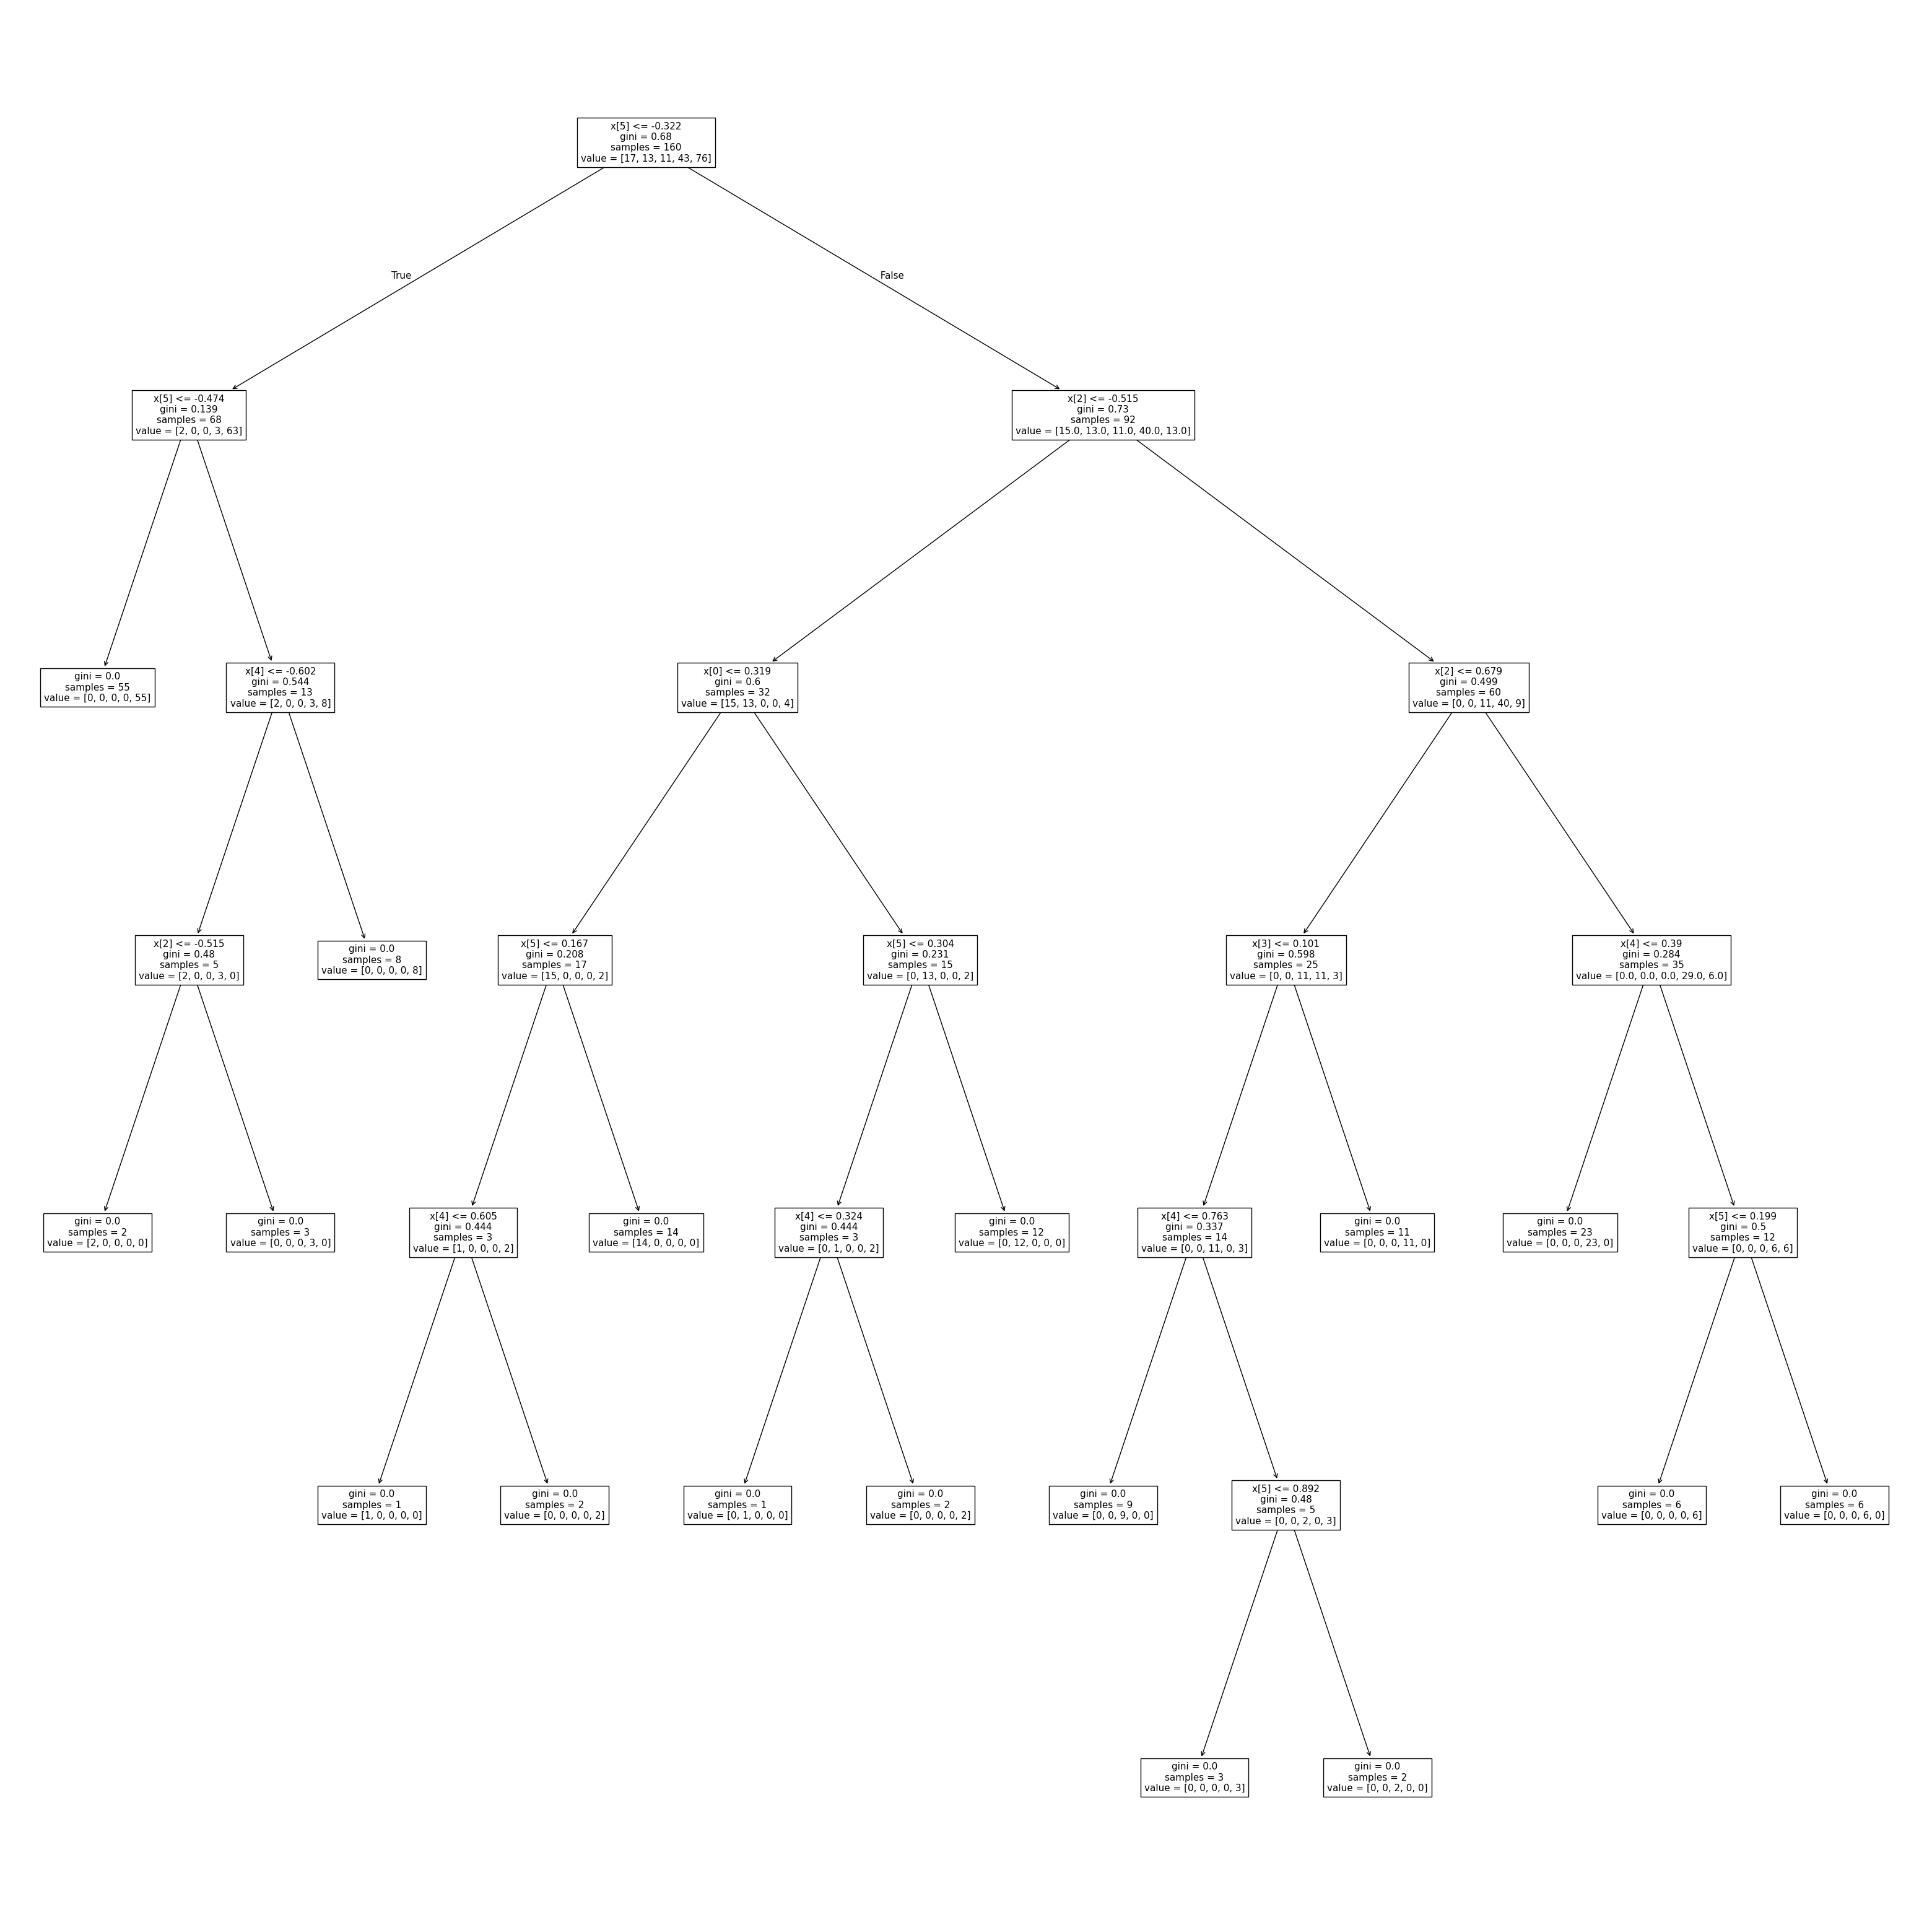

In [13]:
from sklearn import tree
plt.figure(figsize=(40,40))
tree.plot_tree(clf_gini.fit(X_train,y_train))
plt.show()

In [14]:
clf_entropy=DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=0)
clf_entropy.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [15]:
ypred_train=clf_entropy.predict(X_train)
ypred_test=clf_entropy.predict(X_test)

In [16]:
print("Accuracy score:",accuracy_score(ypred_train,y_train))
print("cross validation score:",cross_val_score(clf_entropy,X_train,y_train,cv=6).mean())

Accuracy score: 0.88125
cross validation score: 0.8254985754985754


In [17]:
print("Accuracy score:",accuracy_score(ypred_test,y_test))
print("cross validation score:",cross_val_score(clf_entropy,X_test,y_test,cv=6).mean())

Accuracy score: 0.775
cross validation score: 0.7063492063492064


D:\Ananconda2\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=6.
  warnings.warn(


In [18]:
new_data = pd.DataFrame([{
    'Age': 45,
    'Sex': 1,
    'BP': 1,
    'Cholesterol': 0,
    'Na': 14.5,
    'K': 10
}])

In [19]:
oc = OrdinalEncoder()
df['Drug'] = oc.fit_transform(df[['Drug']])
prediction = clf_gini.predict(new_data)
decoded = oc.inverse_transform([[prediction[0]]])
predicted_drug = decoded[0][0] 
print("Predicted Drug:", predicted_drug)

Predicted Drug: 3.0


D:\Ananconda2\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [20]:
new_data1 = pd.DataFrame([{
    'Age': 60,
    'Sex': 0,          
    'BP': 2,            
    'Cholesterol': 1,   
    'Na': 13.2,
    'K': 6.7
}])

In [21]:
oc = OrdinalEncoder()
df['Drug'] = oc.fit_transform(df[['Drug']])
prediction = clf_gini.predict(new_data1)
decoded = oc.inverse_transform([[prediction[0]]])
predicted_drug = decoded[0][0] 
print("Predicted Drug:", predicted_drug)

Predicted Drug: 3.0


D:\Ananconda2\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [22]:
new2 = pd.DataFrame([{
    'Age': 35,
    'Sex': 1,           
    'BP': 0,            
    'Cholesterol': 0,   
    'Na': 15.3,
    'K': 4.2
}])

In [23]:
oc = OrdinalEncoder()
df['Drug'] = oc.fit_transform(df[['Drug']])
prediction = clf_gini.predict(new2)
decoded = oc.inverse_transform([[prediction[0]]])
predicted_drug = decoded[0][0] 
print("Predicted Drug:", predicted_drug)

Predicted Drug: 2.0


D:\Ananconda2\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


# Bussiness problem

Create the model that can help predict a species of penguin based on physical attributes then we can use
the model to researchers to classify the penguin in the field.instesd of needing an experinced biologiest

In [24]:
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\penguins_size.csv")
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [26]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [27]:
df.isnull().sum()       #There is some missing values

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [28]:
df[df.duplicated()]     #There is no any duplicated values

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex


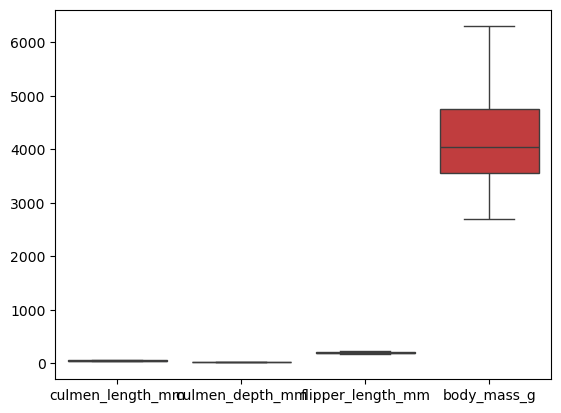

In [29]:
sns.boxplot(data=df)
plt.show()

- Data Cleaning

In [30]:
df=df.dropna()
df.shape

(334, 7)

- Encoding

In [31]:
from sklearn.preprocessing import OrdinalEncoder
oc=OrdinalEncoder()
df['species']=oc.fit_transform(df[['species']])
df['island']=oc.fit_transform(df[['island']])
df['sex']=oc.fit_transform(df[['sex']])
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0.0,2.0,39.1,18.7,181.0,3750.0,2.0
1,0.0,2.0,39.5,17.4,186.0,3800.0,1.0
2,0.0,2.0,40.3,18.0,195.0,3250.0,1.0
4,0.0,2.0,36.7,19.3,193.0,3450.0,1.0
5,0.0,2.0,39.3,20.6,190.0,3650.0,2.0


- X and Y

In [32]:
X=df.drop('species',axis=1)
y=df['species']

- Train Test split

In [81]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=0)

In [82]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [83]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [84]:
ypred_train=clf.predict(X_train)
ypred_test=clf.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score
print("accuracy score of train data:",accuracy_score(ypred_train,y_train))
from sklearn.model_selection import cross_val_score
print("cross validation score of the train data:",cross_val_score(clf,X_train,y_train,cv=5).mean())

accuracy score of train data: 1.0
cross validation score of the train data: 0.9666666666666666


In [86]:
from sklearn.metrics import accuracy_score
print("accuracy score of test data:",accuracy_score(ypred_test,y_test))
from sklearn.model_selection import cross_val_score
print("cross validation score of the train data:",cross_val_score(clf,X_test,y_test,cv=5).mean())

accuracy score of test data: 0.9705882352941176
cross validation score of the train data: 0.9428571428571428


In [87]:
from sklearn.metrics import classification_report
print(classification_report(ypred_test,y_test))

              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97        19
         1.0       0.83      1.00      0.91         5
         2.0       1.00      1.00      1.00        10

    accuracy                           0.97        34
   macro avg       0.94      0.98      0.96        34
weighted avg       0.98      0.97      0.97        34



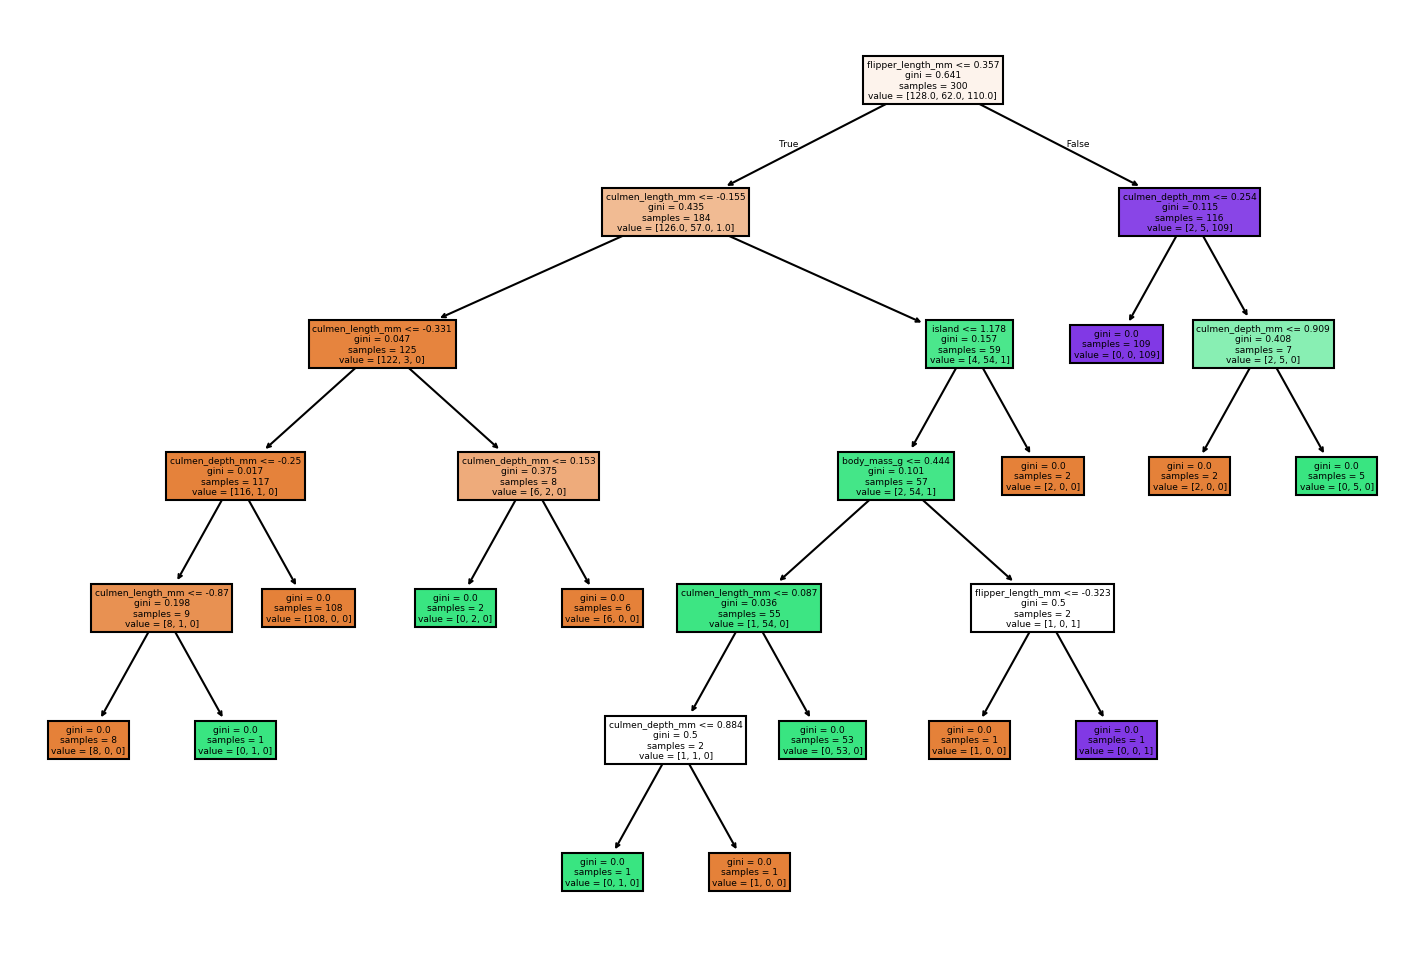

In [88]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8),dpi=150)
plot_tree(clf,filled=True,feature_names=X.columns)
plt.show()

# Optimization pruning of Decision Tree

In [89]:
pruned_tree=DecisionTreeClassifier(max_depth=2)

accuracy score: 0.9666666666666667
accuracy score: 0.9411764705882353


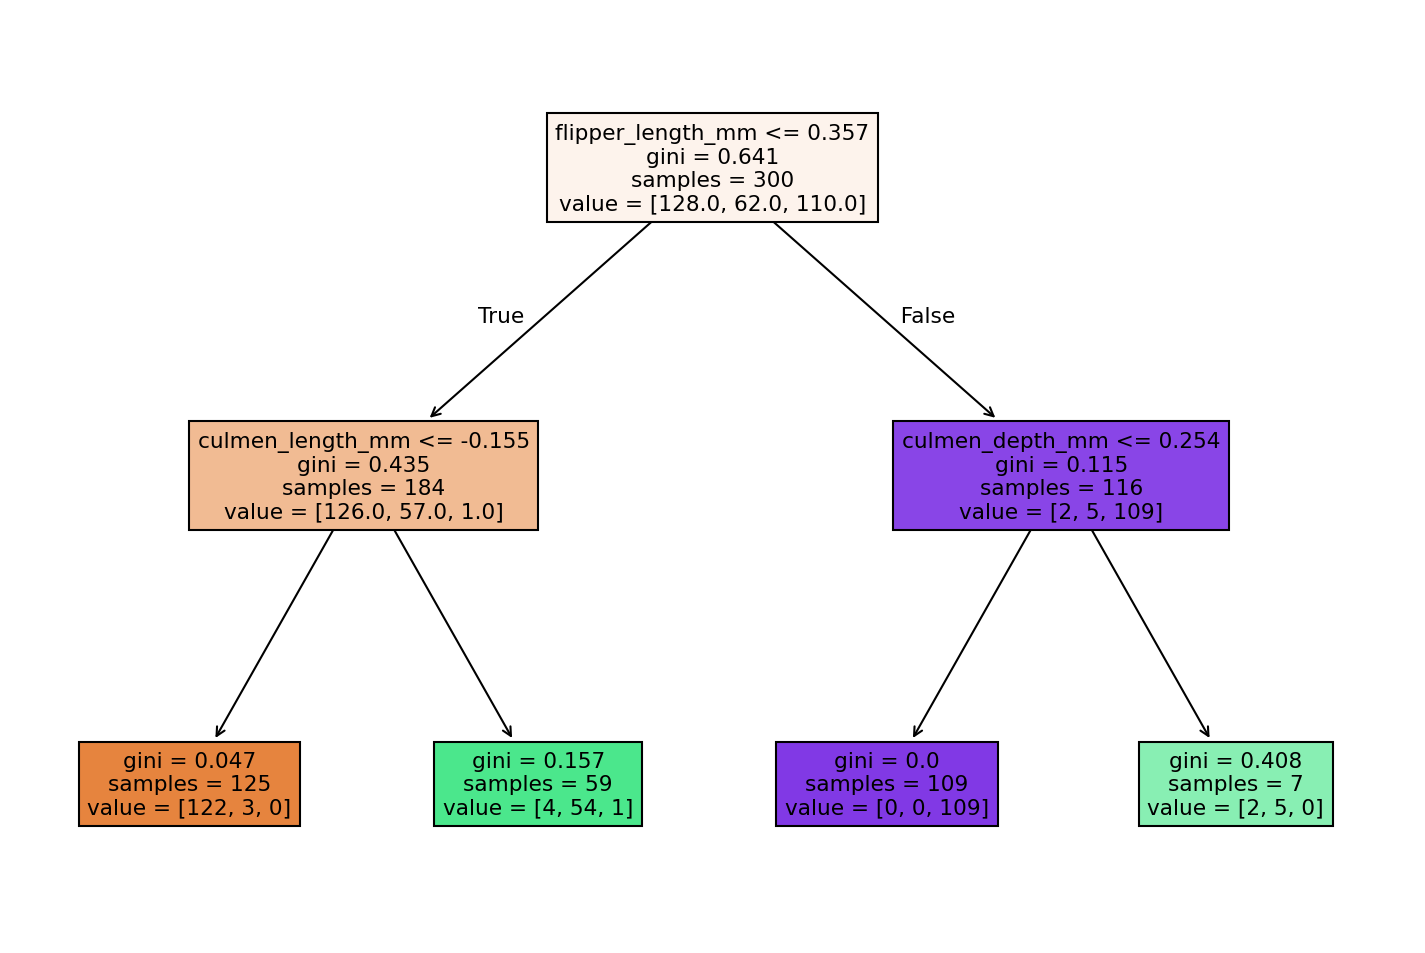

In [90]:
def report_model(clf):
    clf.fit(X_train,y_train)
    clf_train=clf.predict(X_train)
    clf_test=clf.predict(X_test)
    print("accuracy score:",accuracy_score(y_train,clf_train))
    print("accuracy score:",accuracy_score(y_test,clf_test))
    plt.figure(figsize=(12,8),dpi=150)
    plot_tree(clf,filled=True,feature_names=X.columns)
report_model(pruned_tree)

accuracy score: 0.95
accuracy score: 0.9411764705882353


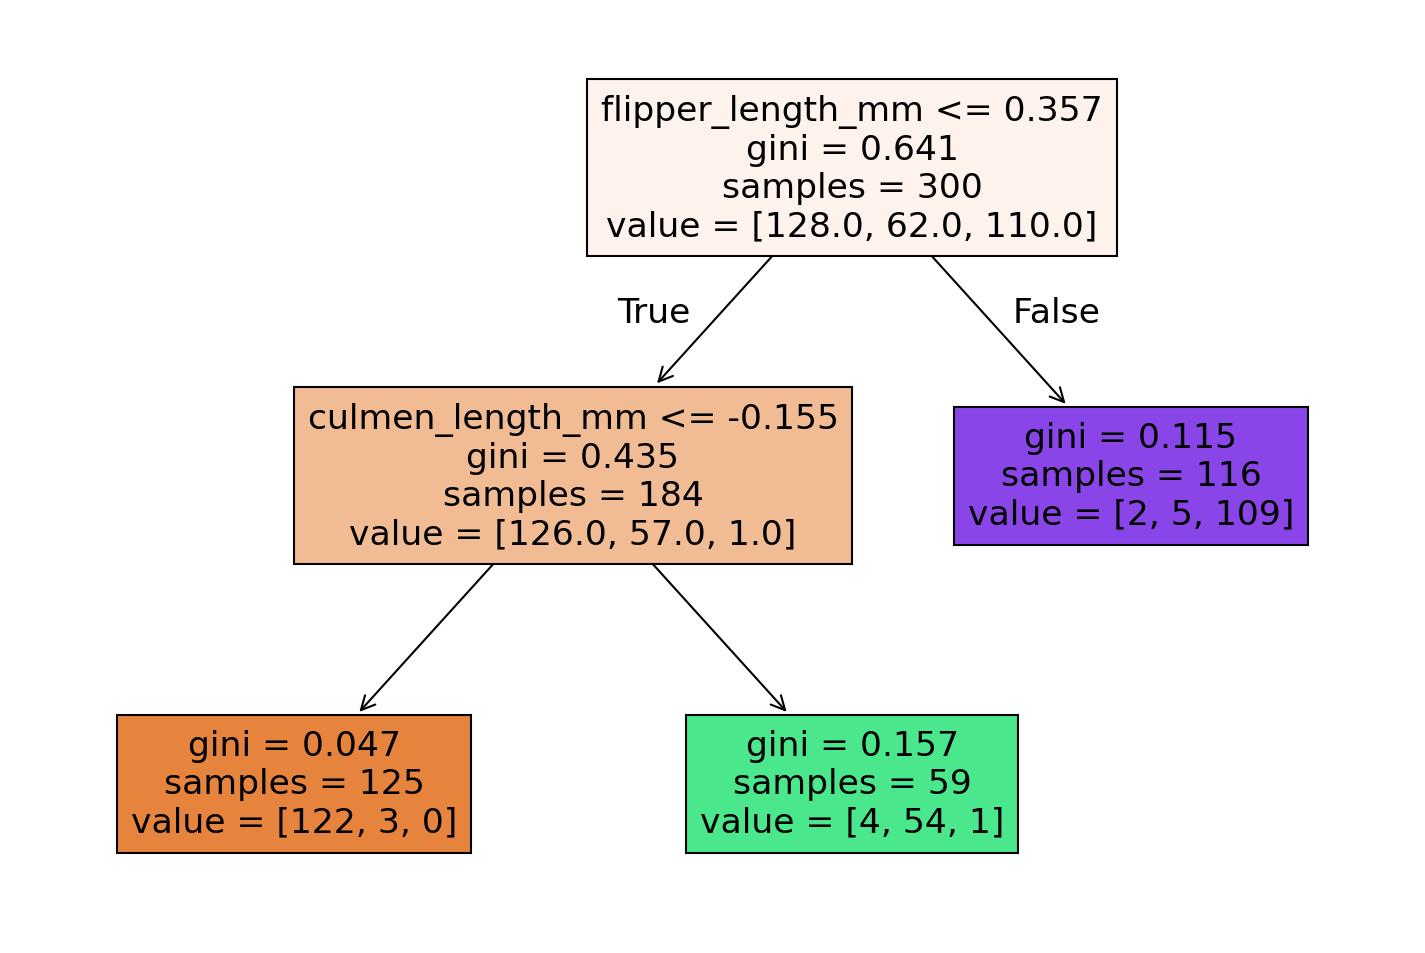

In [91]:
pruned_tree=DecisionTreeClassifier(max_leaf_nodes=3)
report_model(pruned_tree)

In [92]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0.0,2.0,39.1,18.7,181.0,3750.0,2.0
1,0.0,2.0,39.5,17.4,186.0,3800.0,1.0
2,0.0,2.0,40.3,18.0,195.0,3250.0,1.0
4,0.0,2.0,36.7,19.3,193.0,3450.0,1.0
5,0.0,2.0,39.3,20.6,190.0,3650.0,2.0


In [93]:
new_data = pd.DataFrame([{
    "island": 2.0,
    "culmen_length_mm": 36.7,
    "culmen_depth_mm": 19.3,
    "flipper_length_mm": 193.0,
    "body_mass_g": 3450.0,
    "sex": 1.0
}])

In [94]:
oc = OrdinalEncoder()
df['species'] = oc.fit_transform(df[['species']])
prediction = clf.predict(new_data)
decoded = oc.inverse_transform([[prediction[0]]])
predicted_species = decoded[0][0] 
print("Predicted species:", predicted_species)

Predicted species: 1.0


D:\Ananconda2\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [95]:
new_data_2 = pd.DataFrame({
    "island": [2.0],
    "culmen_length_mm": [40.0],
    "culmen_depth_mm": [17.9],
    "flipper_length_mm": [192.0],
    "body_mass_g": [3700.0],
    "sex": [2.0]  
})

In [96]:
oc = OrdinalEncoder()
df['species'] = oc.fit_transform(df[['species']])
prediction = clf.predict(new_data_2)
decoded = oc.inverse_transform([[prediction[0]]])
predicted_species = decoded[0][0] 
print("Predicted species:", predicted_species)

Predicted species: 1.0


D:\Ananconda2\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
